In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


## 데이터전처리

수요공급 커브 data: OMIE, Aggregate supply and demand curves of Day-ahead market

In [7]:
# 1) 바꿀 헤더명 매핑 딕셔너리
mapping = {
    'Periodo':      'Time Period',
    'Fecha':        'Date',
    'Precio Compra/Venta':         'Price',
    'Potencia Compra/Venta':       'Amount',
    'Tipo Oferta':  'GC'
}


# 1) 마지막 점만 유지하는 함수
def keep_last_dot(s: str) -> str:
    # '1.800.3' → '1800.3'
    return re.sub(r'\.(?=[^.]*\.)', '', s)

# 2) 7/20 부터 7/27 까지 반복
for day in range(30, 32):
    date_str = f"202507{day:02d}"
    in_file  = f"curva_pbc_{date_str}.1"
    out_file = f"curve_{date_str}.csv"

    if os.path.isfile(in_file):
        # 읽기
        df = pd.read_csv(
            in_file,
            sep=';',
            encoding='latin-1',
            skiprows=2
        )

        # 헤더명 변경 (매핑에 없는 컬럼은 그대로)
        df = df.rename(columns=mapping)

        # 저장 (utf-8-sig: Excel 호환)
        df.to_csv(
            out_file,
            index=False,
            encoding='utf-8-sig'
        )
        print(f"✔ Converted: {in_file} → {out_file}")
    else:
        print(f"⚠ File not found: {in_file}")


✔ Converted: curva_pbc_20250730.1 → curve_20250730.csv
✔ Converted: curva_pbc_20250731.1 → curve_20250731.csv


In [8]:
pattern = r'\.(?=[^.]*\.)'

for day in range(30, 32):
    date_str = f"202507{day:02d}"
    in_file  = f"curve_{date_str}.csv"
    out_file = f"filteredcurve_{date_str}.csv"

    try:
        # 1) CSV 읽기 (기본 구분자 ',' 사용)
        df = pd.read_csv(in_file, sep=',', encoding='utf-8-sig')
        
        # 2) Price/Amount 문자열 처리
        df['Price']  = (df['Price'].astype(str)
                             .str.replace(',', '.', regex=False)
                             .apply(lambda s: re.sub(pattern, '', s)))
        df['Amount'] = (df['Amount'].astype(str)
                             .str.replace(',', '.', regex=False)
                             .apply(lambda s: re.sub(pattern, '', s)))
        
        # 3) Numeric 타입 변환
        df['Price']  = pd.to_numeric(df['Price'],  errors='coerce')
        df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
        
        # 4) 저장
        df.to_csv(out_file, sep=',', index=False, encoding='utf-8-sig')
        print(f"✔ {in_file} → {out_file}")
    except FileNotFoundError:
        print(f"⚠ 파일이 없습니다: {in_file}")

✔ curve_20250730.csv → filteredcurve_20250730.csv
✔ curve_20250731.csv → filteredcurve_20250731.csv


날씨 data: OGIMET, Madrid(08221) 기준

In [15]:
# 1. 데이터 불러오기
df = pd.read_excel("weather0903.xlsx")

# 2. Date 컬럼 변환 (일/월/연도)
df["Date"] = pd.to_datetime(df["Date"]).dt.strftime("%d/%m/%Y")

# 3. Time → 정수 (0시=1, 1시=2, … 23시=24)
if pd.api.types.is_datetime64_any_dtype(df["Time"]):
    # 이미 datetime으로 읽힌 경우
    df["Hour"] = df["Time"].dt.hour + 1
else:
    # 문자열인 경우
    df["Hour"] = pd.to_datetime(df["Time"].astype(str)).dt.hour + 1

# 4. 저장
df.to_csv("weather_transformed.csv", index=False, encoding="utf-8-sig")
print("✅ 변환 완료: weather_transformed.csv 저장됨")


✅ 변환 완료: weather_transformed.csv 저장됨


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_27132\1787825919.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"].astype(str)).dt.hour + 1


In [125]:
df_weather = pd.read_csv("weather_transformed.csv")

print(df_weather.columns.tolist())


['Date', 'Time', 'T', 'Td', 'Hr', 'Tmax', 'Tmin', 'ddd', 'ff', 'Gust', 'P0', 'P sea', 'P', 'Prec', 'N', 'N.1', 'H', 'Inso', 'Vis', 'WW', 'W1', 'W2', 'Hour']


In [126]:
df_weather["T"] = pd.to_numeric(df_weather["T"], errors="coerce")
df_weather["ff"] = pd.to_numeric(df_weather["ff"], errors="coerce")

## 클러스터링

Trial 2: 날짜와 시간단위로

In [ ]:
# # Hour를 int → str로 바꾸기
# df_weather["Hour"] = df_weather["Hour"].astype(str)

# # 그냥 Date랑 Hour 문자열 합치기
# df_weather["Datetime"] = df_weather["Date"].astype(str) + " " + df_weather["Hour"]

# print(df_weather[["Date", "Hour", "Datetime"]].head(10))


         Date  Hour         Datetime
0         NaN   nan          nan nan
1  31/07/2025  24.0  31/07/2025 24.0
2  31/07/2025  23.0  31/07/2025 23.0
3  31/07/2025  22.0  31/07/2025 22.0
4  31/07/2025  21.0  31/07/2025 21.0
5  31/07/2025  20.0  31/07/2025 20.0
6  31/07/2025  19.0  31/07/2025 19.0
7  31/07/2025  18.0  31/07/2025 18.0
8  31/07/2025  17.0  31/07/2025 17.0
9  31/07/2025  16.0  31/07/2025 16.0


In [ ]:
# # Hour → 정수 변환 (NaN은 0으로 대체)
# df_weather["Hour"] = pd.to_numeric(df_weather["Hour"], errors="coerce").fillna(0).astype(int)

# # Date를 YYYYMMDD 문자열로 변환
# df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce").dt.strftime("%Y%m%d")

# # Datetime = YYYYMMDD + Hour
# df_weather["Datetime"] = df_weather["Date"] + df_weather["Hour"].astype(str)

# print(df_weather[["Date", "Hour", "Datetime"]].head(10))


       Date  Hour    Datetime
0       NaN     0         NaN
1  20250731    24  2025073124
2  20250731    23  2025073123
3  20250731    22  2025073122
4  20250731    21  2025073121
5  20250731    20  2025073120
6  20250731    19  2025073119
7  20250731    18  2025073118
8  20250731    17  2025073117
9  20250731    16  2025073116


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_27132\3125859838.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce").dt.strftime("%Y%m%d")


In [127]:
# Hour → 숫자로 변환 (변환 불가는 NaN)
df_weather["Hour"] = pd.to_numeric(df_weather["Hour"], errors="coerce")

# NaN 값 제거
df_weather = df_weather.dropna(subset=["Hour"])

# int 변환
df_weather["Hour"] = df_weather["Hour"].astype(int)

# Date를 datetime으로 변환
df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce")

# Datetime 생성: "20250731 13"
df_weather["Datetime"] = df_weather["Date"].dt.strftime("%Y%m%d") + " " + df_weather["Hour"].astype(str)

print(df_weather[["Date", "Hour", "Datetime"]].head(20))


         Date  Hour     Datetime
1  2025-07-31    24  20250731 24
2  2025-07-31    23  20250731 23
3  2025-07-31    22  20250731 22
4  2025-07-31    21  20250731 21
5  2025-07-31    20  20250731 20
6  2025-07-31    19  20250731 19
7  2025-07-31    18  20250731 18
8  2025-07-31    17  20250731 17
9  2025-07-31    16  20250731 16
10 2025-07-31    15  20250731 15
11 2025-07-31    14  20250731 14
12 2025-07-31    13  20250731 13
13 2025-07-31    12  20250731 12
14 2025-07-31    11  20250731 11
15 2025-07-31    10  20250731 10
16 2025-07-31     9   20250731 9
17 2025-07-31     8   20250731 8
18 2025-07-31     7   20250731 7
19 2025-07-31     6   20250731 6
20 2025-07-31     5   20250731 5


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_27132\501971660.py:11: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce")


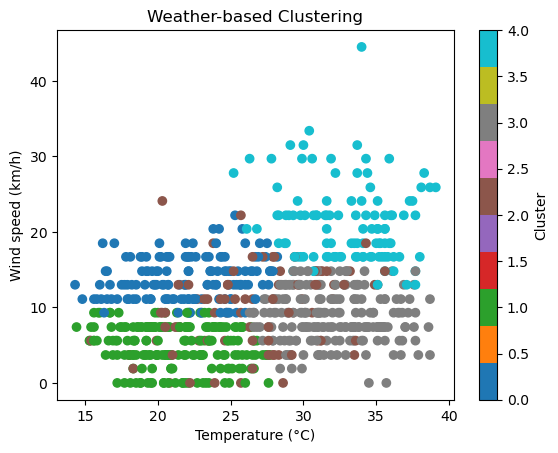

In [128]:
# 1. 클러스터링에 쓸 feature 선택 (기온, 풍속, 강수량 등)
features = df_weather[["T", "ff", "Prec"]].replace("----", 0)
features = features.apply(pd.to_numeric, errors="coerce").fillna(0)

# 2. 정규화 (스케일 차이 보정)
scaler = StandardScaler()
X = scaler.fit_transform(features)

# 3. KMeans 클러스터링 (예: 5개 클러스터)
kmeans = KMeans(n_clusters=5, random_state=42)
df_weather["Cluster"] = kmeans.fit_predict(X)

plt.scatter(df_weather["T"], df_weather["ff"], c=df_weather["Cluster"], cmap="tab10")
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind speed (km/h)")
plt.title("Weather-based Clustering")
plt.colorbar(label="Cluster")
plt.show()


In [ ]:
# files = glob.glob("filteredcurve_202507*.csv")
# df_list = []
# for fn in files:
#     temp = pd.read_csv(fn, encoding="utf-8-sig")

#     # 파일명에서 날짜 추출
#     date_str = fn.split("_")[-1].split(".")[0]   # "20250720"
#     temp["Date"] = pd.to_datetime(date_str, format="%Y%m%d").date()

#     # 공급곡선의 Period → Hour 변환 (1~24 → 0~23)
#     temp = temp.dropna(subset=["Time Period"])
#     temp["Hour"] = temp["Time Period"].astype(int)

#     # Datetime 만들기
#     temp["Datetime"] = temp["Date"].astype(str) + " " + temp["Hour"].astype(str)

#     df_list.append(temp)

# df_supply = pd.concat(df_list, ignore_index=True)
# print(df_supply[["Date", "Hour", "Datetime"]].head())


         Date  Hour      Datetime
0  2025-07-01     1  2025-07-01 1
1  2025-07-01     1  2025-07-01 1
2  2025-07-01     1  2025-07-01 1
3  2025-07-01     1  2025-07-01 1
4  2025-07-01     1  2025-07-01 1


In [130]:
files = glob.glob("filteredcurve_202507*.csv")
df_list = []
for fn in files:
    temp = pd.read_csv(fn, encoding="utf-8-sig")

    # 파일명에서 날짜 추출
    date_str = fn.split("_")[-1].split(".")[0]   # "20250720"
    temp["Date"] = pd.to_datetime(date_str, format="%Y%m%d")

    # 공급곡선의 Period → Hour 변환 (1~24 → 0~23)
    temp = temp.dropna(subset=["Time Period"])
    temp["Hour"] = temp["Time Period"].astype(int)

    # Datetime 만들기 (같은 포맷: "20250720 0")
    temp["Datetime"] = temp["Date"].dt.strftime("%Y%m%d") + " " + temp["Hour"].astype(str)

    df_list.append(temp)

df_supply = pd.concat(df_list, ignore_index=True)

print(df_supply[["Date", "Hour", "Datetime"]].head())


        Date  Hour    Datetime
0 2025-07-01     1  20250701 1
1 2025-07-01     1  20250701 1
2 2025-07-01     1  20250701 1
3 2025-07-01     1  20250701 1
4 2025-07-01     1  20250701 1


In [131]:
supply_curves = []

# ① Datetime → Cluster 매핑 dict 만들기
cluster_map = dict(zip(df_weather["Datetime"], df_weather["Cluster"]))

# ② 공급곡선 + 수요곡선 생성
for (date, hour), sub in df_supply.groupby(["Date", "Hour"]):
    sup = sub[sub["GC"] == "V"].copy()   # 공급
    dem = sub[sub["GC"] == "C"].copy()   # 수요
    if sup.empty or dem.empty:
        continue
    
    # 공급곡선 집계
    s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    # 수요곡선 집계
    d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]
    
    # Datetime (앞에서 만든 포맷과 동일)
    dt = pd.to_datetime(date).strftime("%Y%m%d") + " " + str(hour)
    
    # 이 Datetime이 어떤 클러스터인지 확인
    cluster = cluster_map.get(dt, None)
    
    supply_curves.append({
        "Datetime": dt,
        "Cluster": cluster,
        "Supply": s_agg,
        "Demand": d_agg
    })

# 결과 확인
for c in supply_curves[:3]:
    print("Datetime:", c["Datetime"], "Cluster:", c["Cluster"])
    print("Supply head:\n", c["Supply"].head(), "\n")


Datetime: 20250701 1 Cluster: 1
Supply head:
    Price  Amount   Cumul
0 -500.0  7985.4  7985.4
1 -120.0    90.0  8075.4
2 -100.0   161.6  8237.0
3  -80.0     7.2  8244.2
4  -60.0    61.0  8305.2 

Datetime: 20250701 2 Cluster: 1
Supply head:
    Price  Amount   Cumul
0 -500.0  7972.9  7972.9
1 -120.0    90.0  8062.9
2 -100.0    89.4  8152.3
3  -80.0     6.2  8158.5
4  -60.0    53.0  8211.5 

Datetime: 20250701 3 Cluster: 1
Supply head:
    Price  Amount   Cumul
0 -500.0  7808.5  7808.5
1 -120.0    90.0  7898.5
2 -100.0    39.4  7937.9
3  -80.0     4.6  7942.5
4  -60.0    48.2  7990.7 



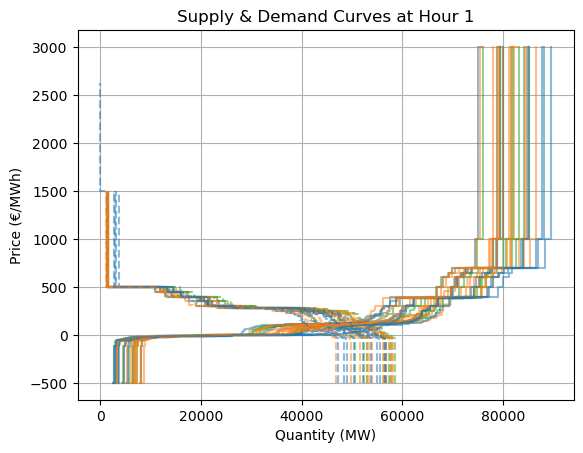

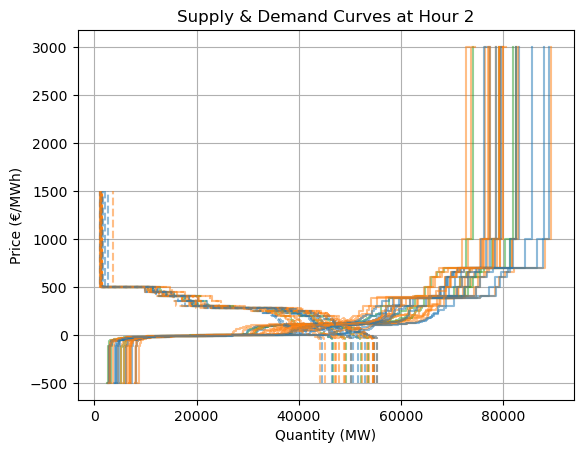

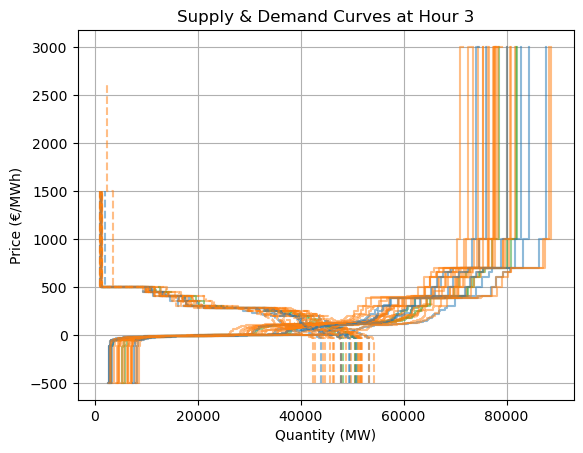

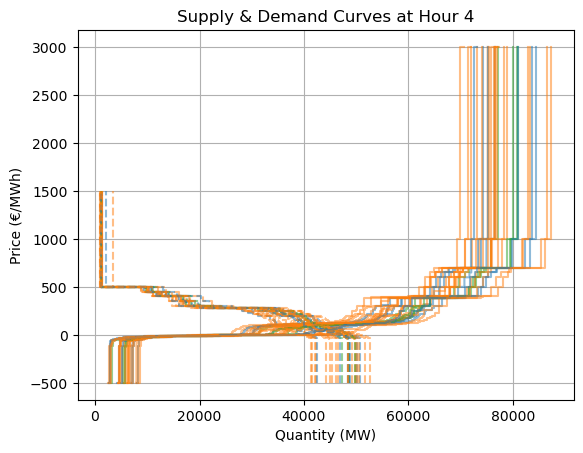

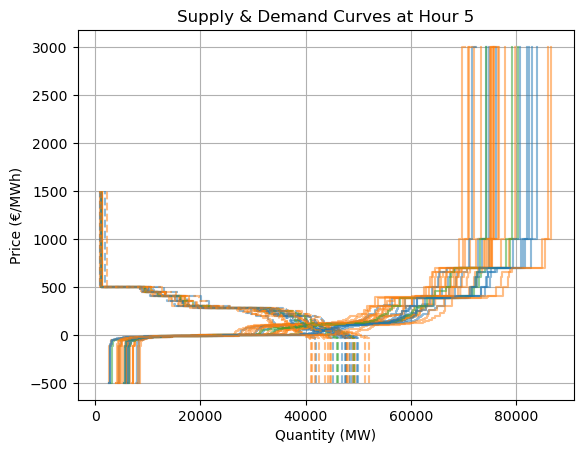

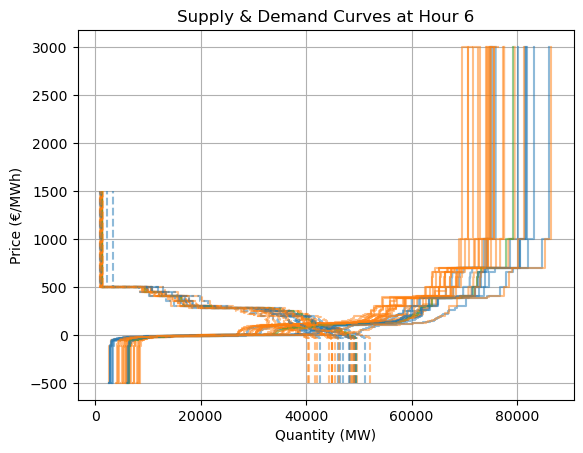

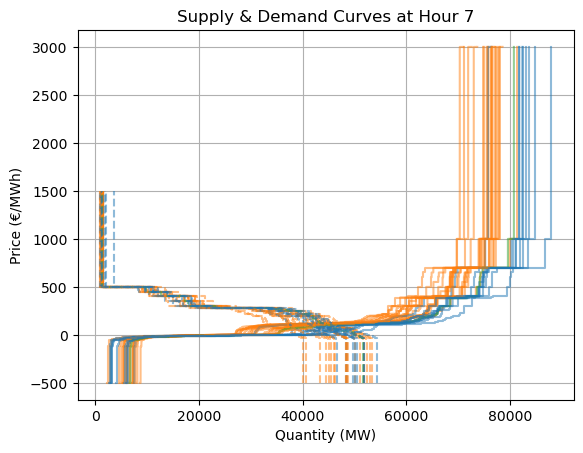

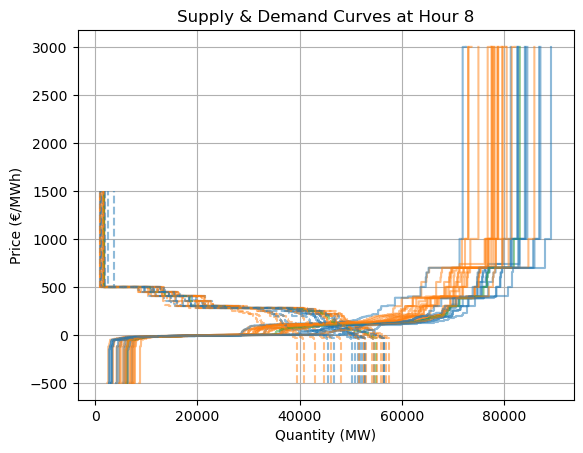

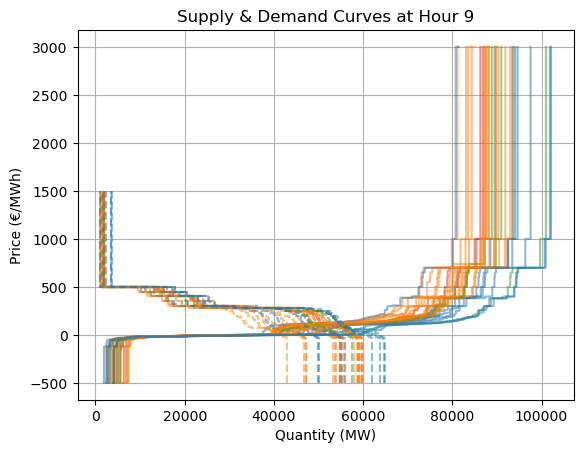

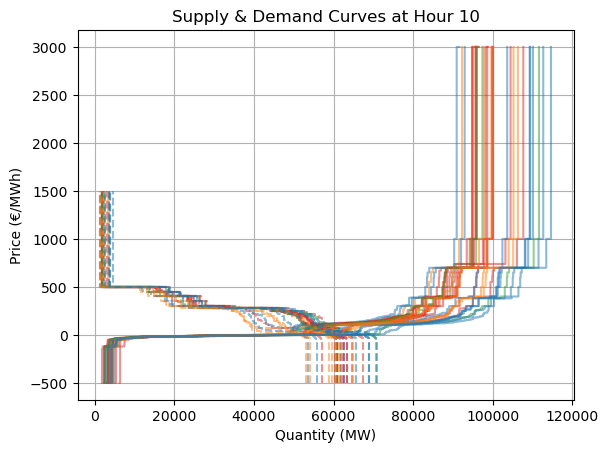

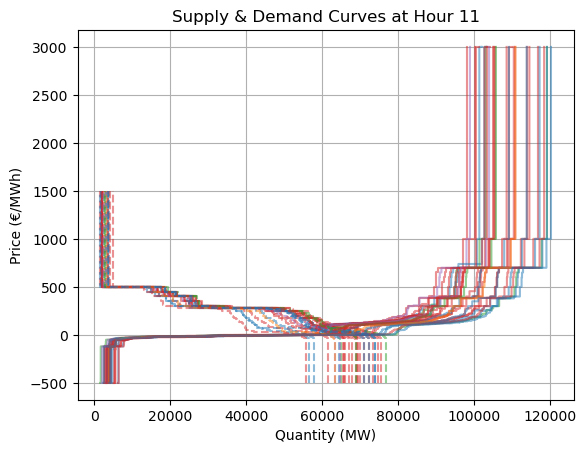

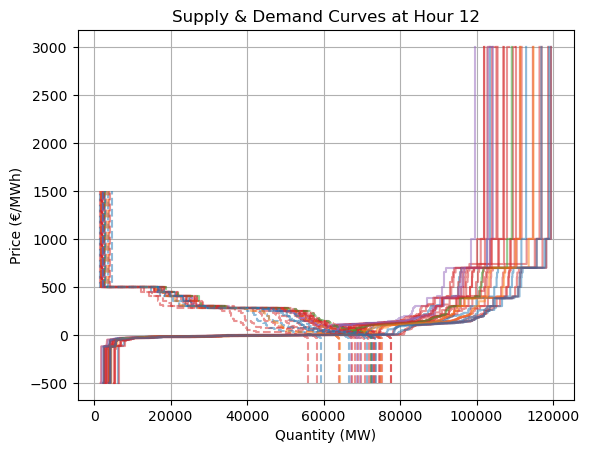

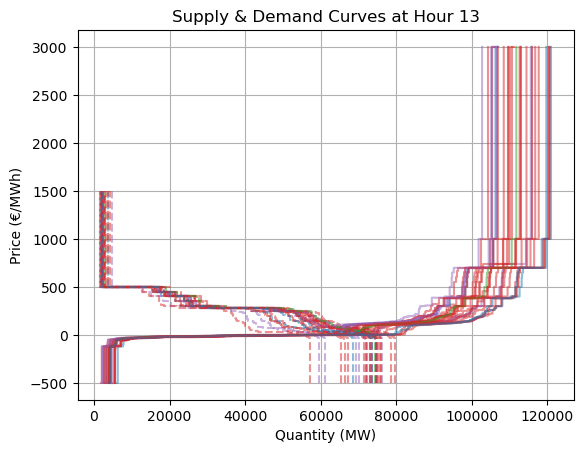

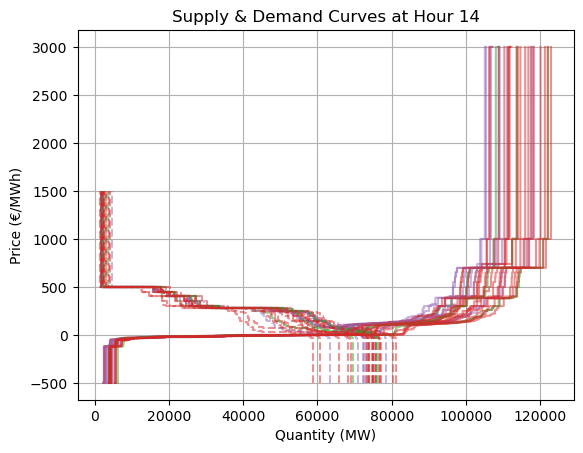

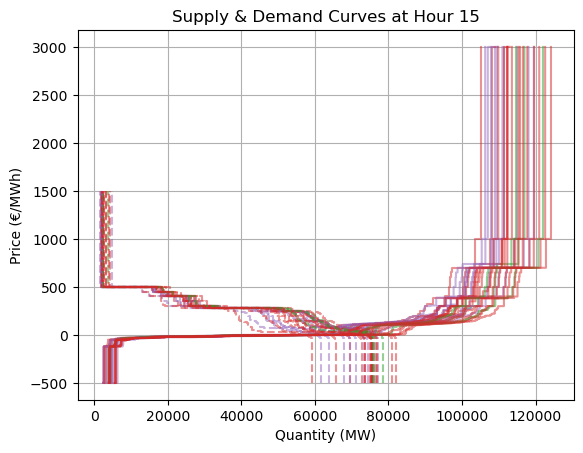

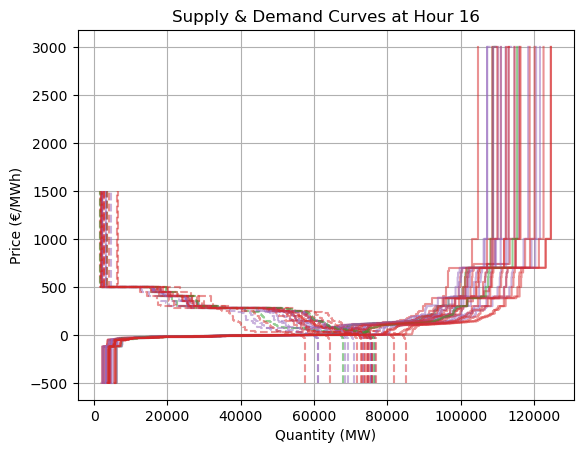

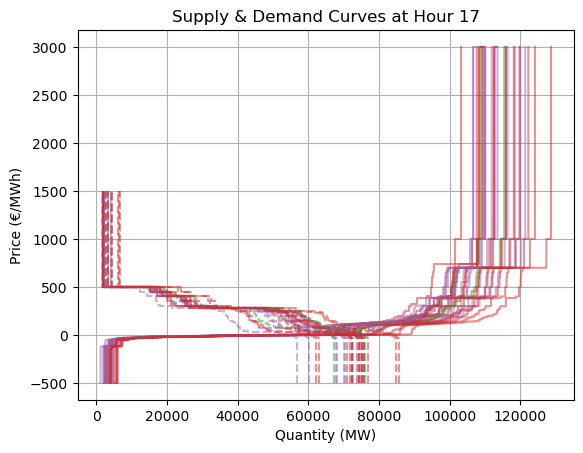

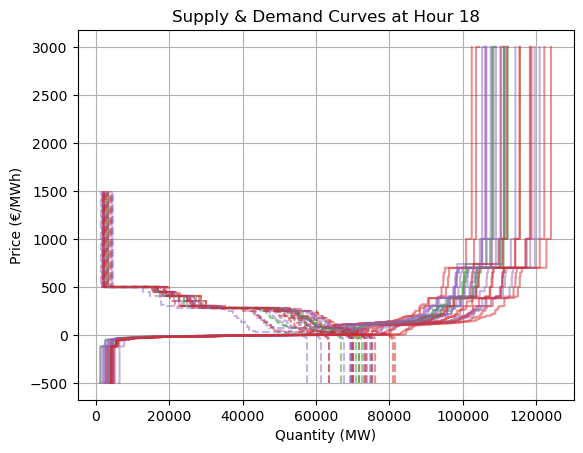

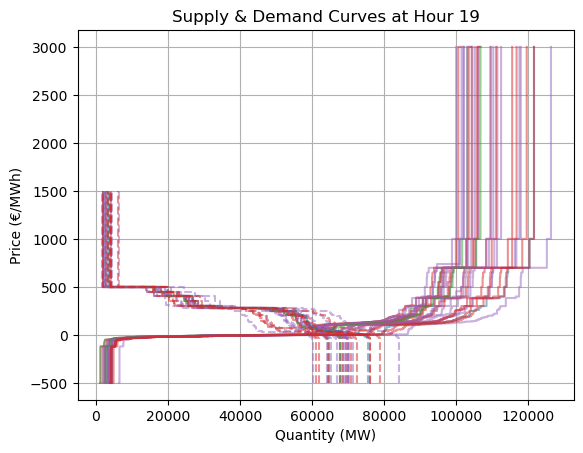

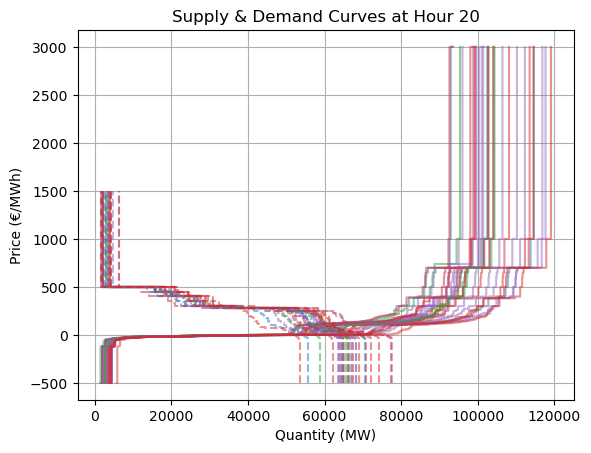

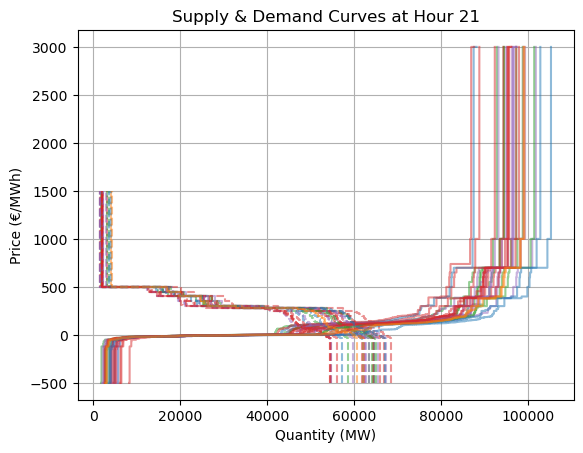

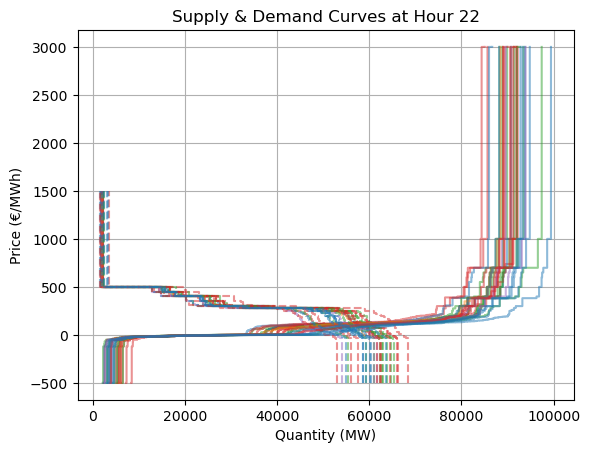

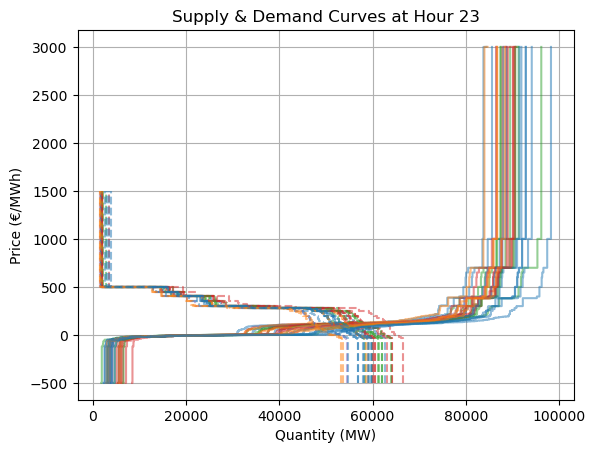

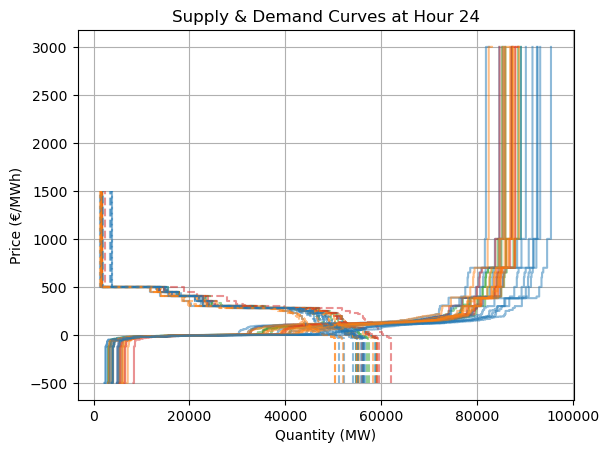

In [135]:
# import matplotlib.cm as cm

colors = cm.tab10

for h in range(1, 25):  # 1~24    plt.figure(figsize=(8,6))
    
    for curve in supply_curves:
        cluster = curve["Cluster"]
        if cluster is None:
            continue
        
        # Datetime에서 Hour 추출
        hour = int(curve["Datetime"].split()[-1])
        if hour != h:
            continue
        
        # 공급곡선 (실선)
        plt.step(
            curve["Supply"]["Cumul"], curve["Supply"]["Price"],
            where="post", color=colors(cluster % 10), alpha=0.5
        )
        
        # 수요곡선 (점선)
        plt.step(
            curve["Demand"]["Cumul"], curve["Demand"]["Price"],
            where="post", color=colors(cluster % 10), linestyle="--", alpha=0.5
        )
    
    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.title(f"Supply & Demand Curves at Hour {h}")
    plt.grid(True)
    plt.show()


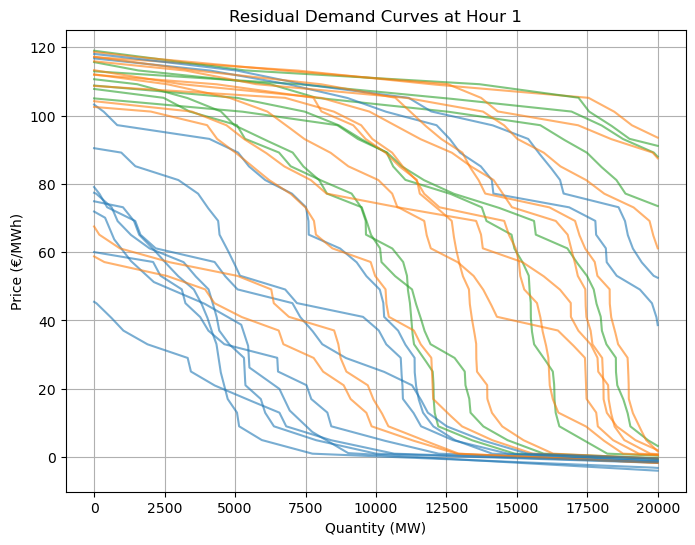

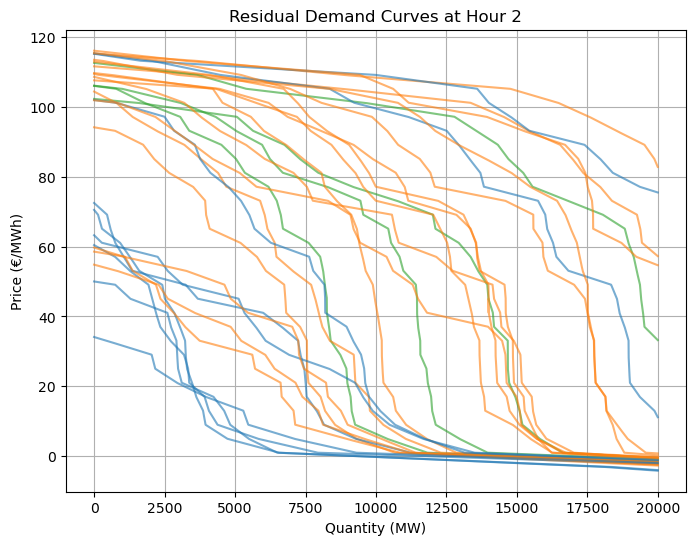

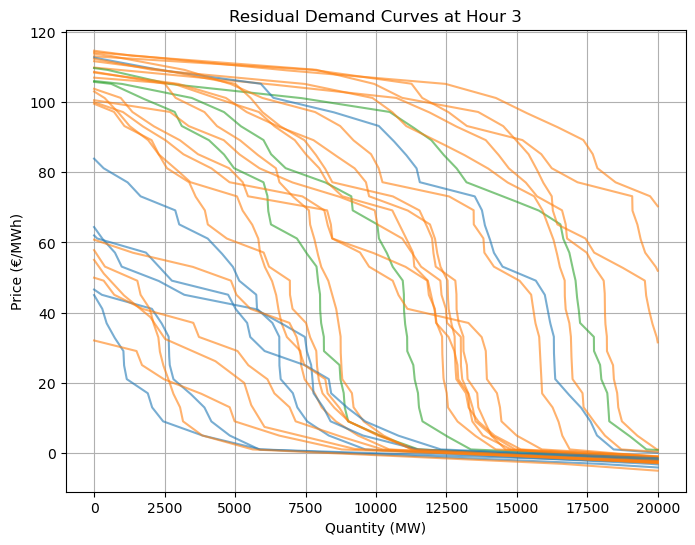

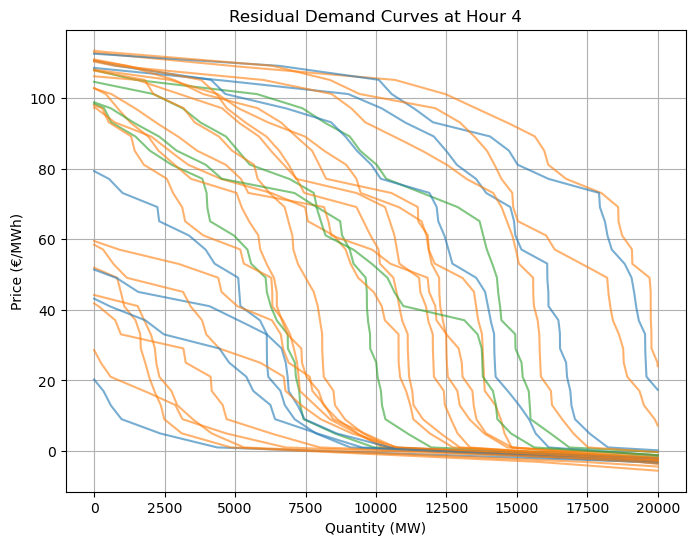

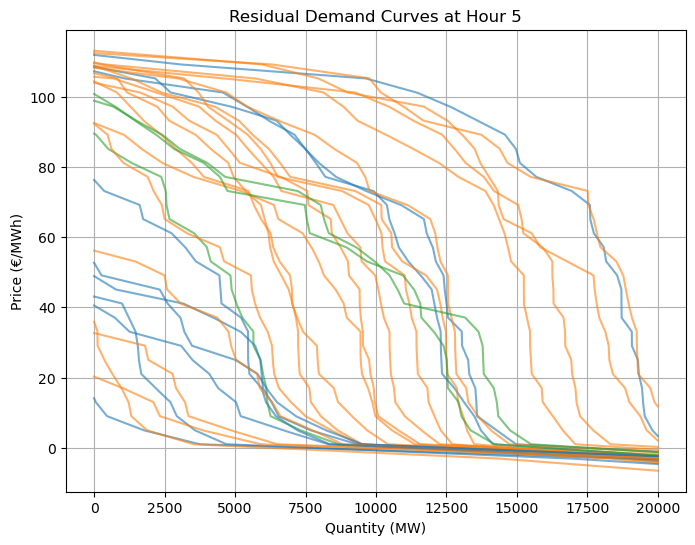

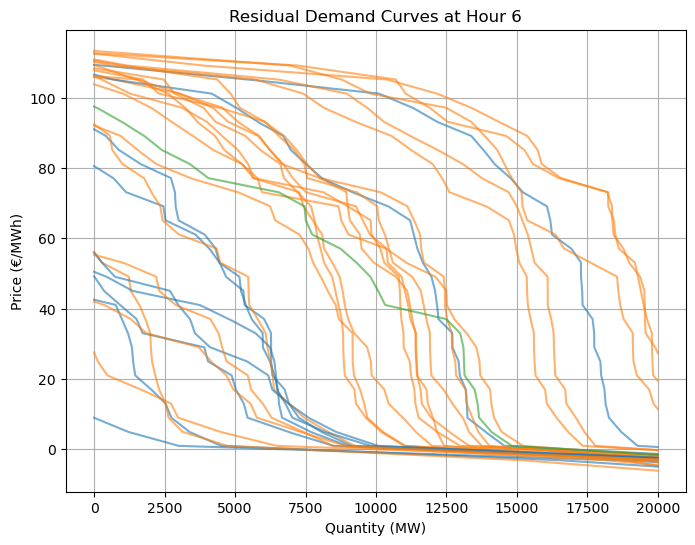

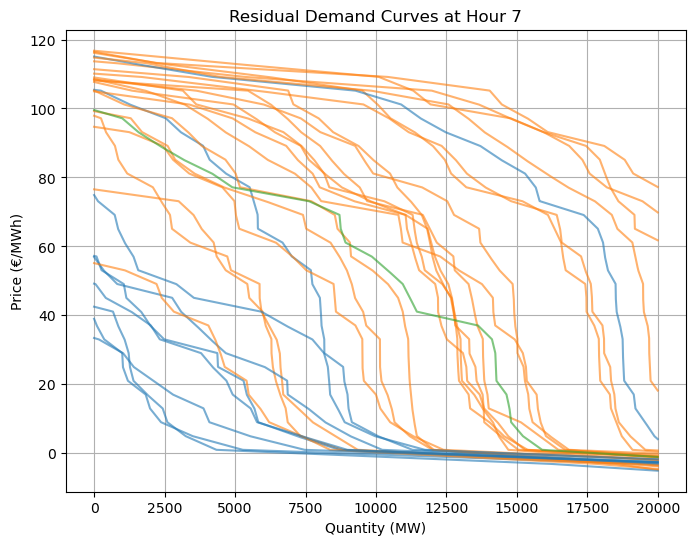

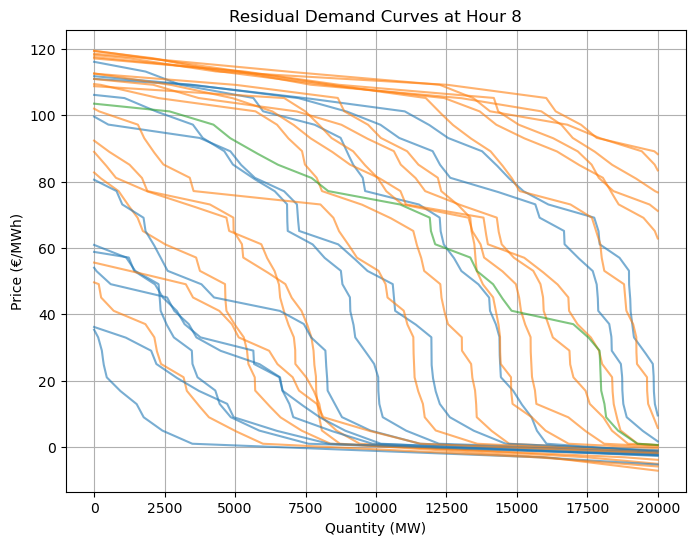

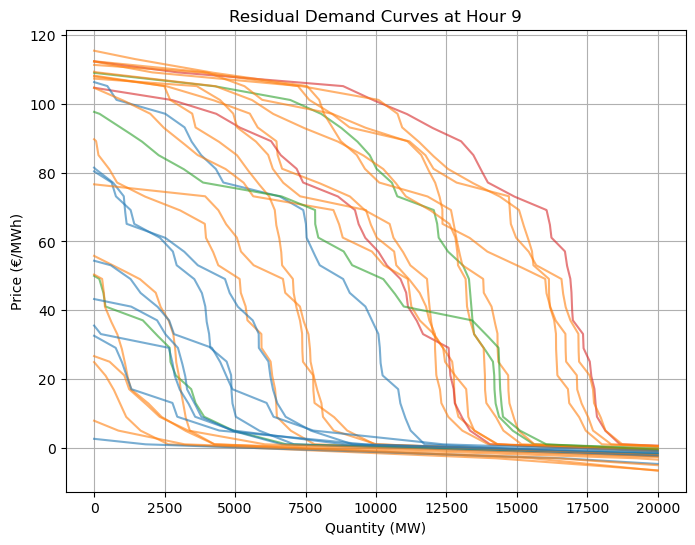

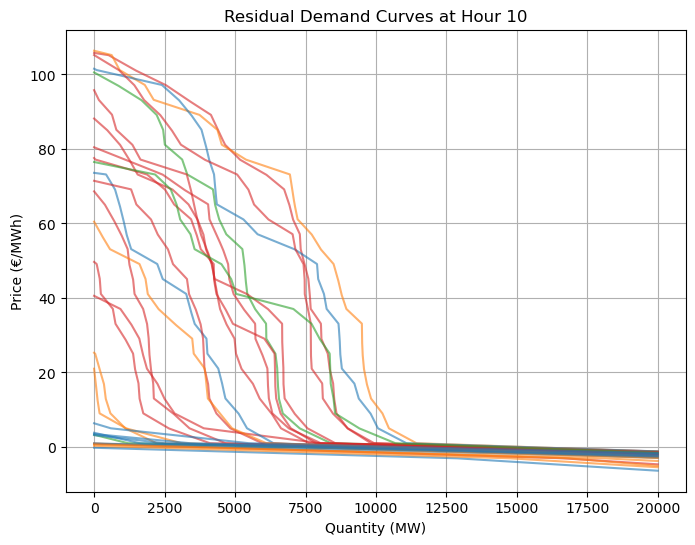

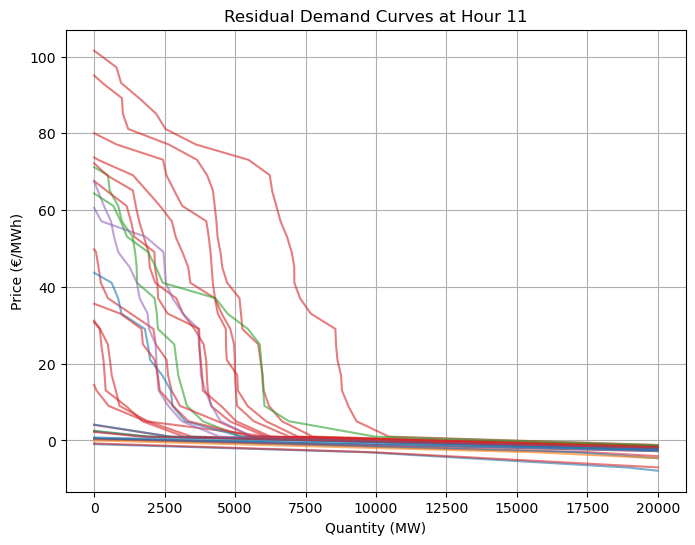

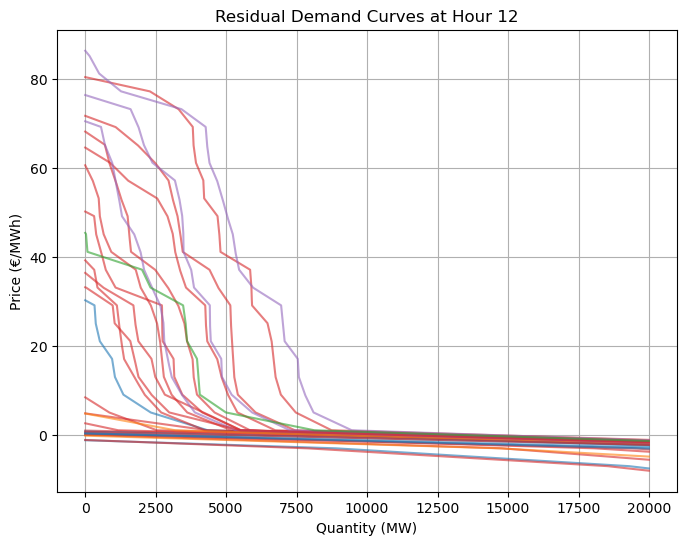

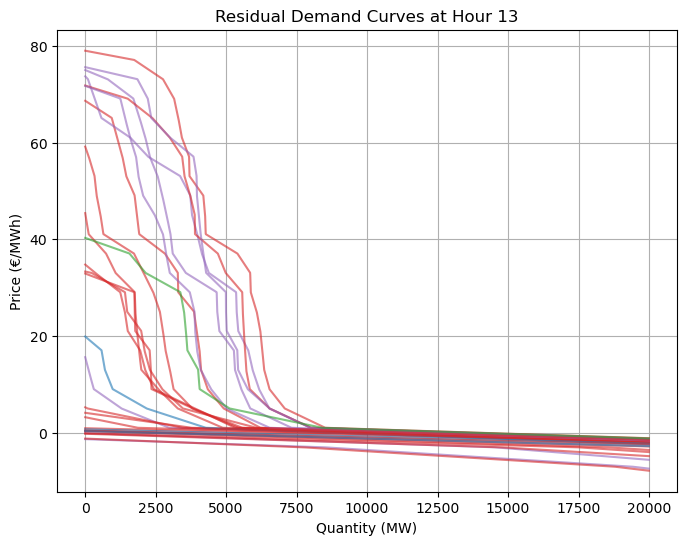

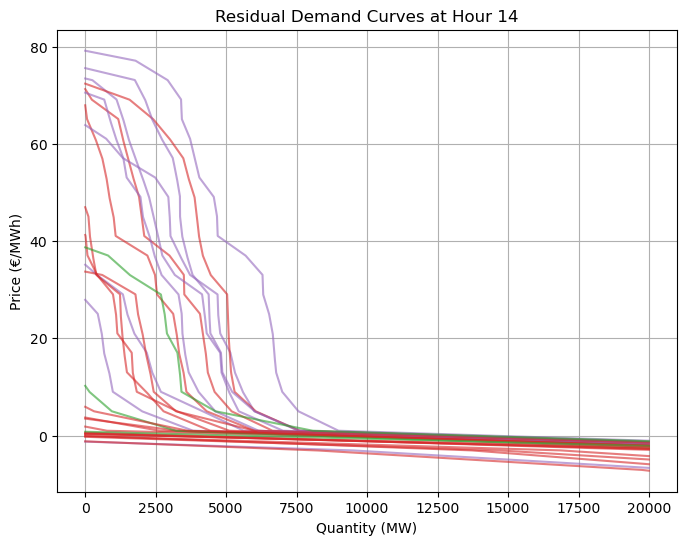

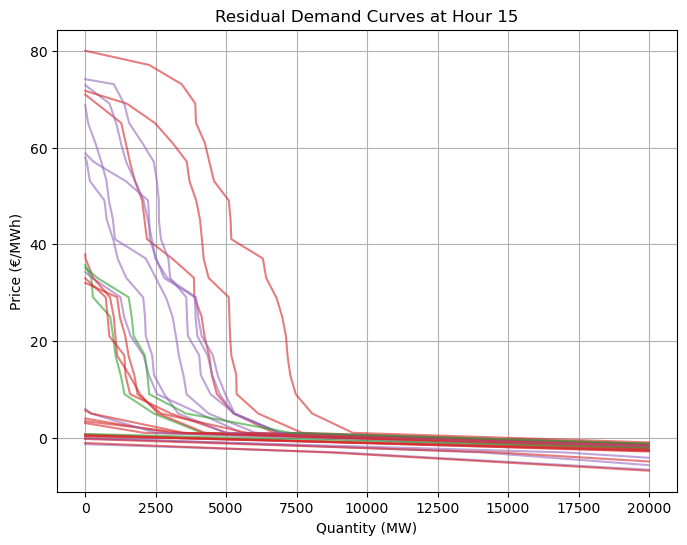

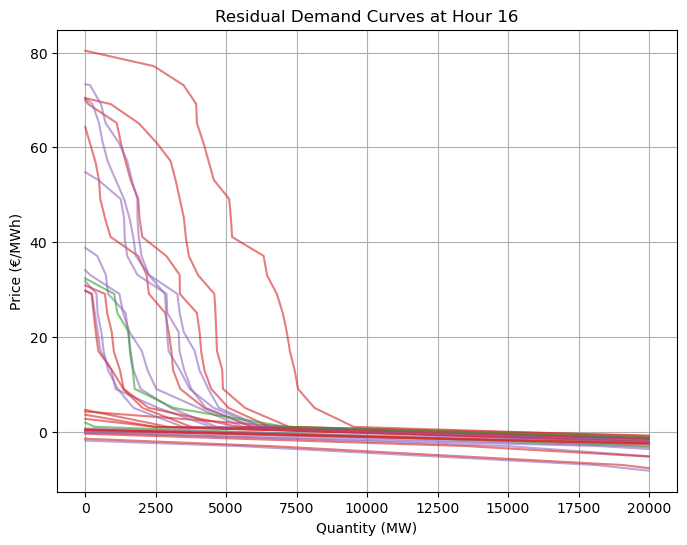

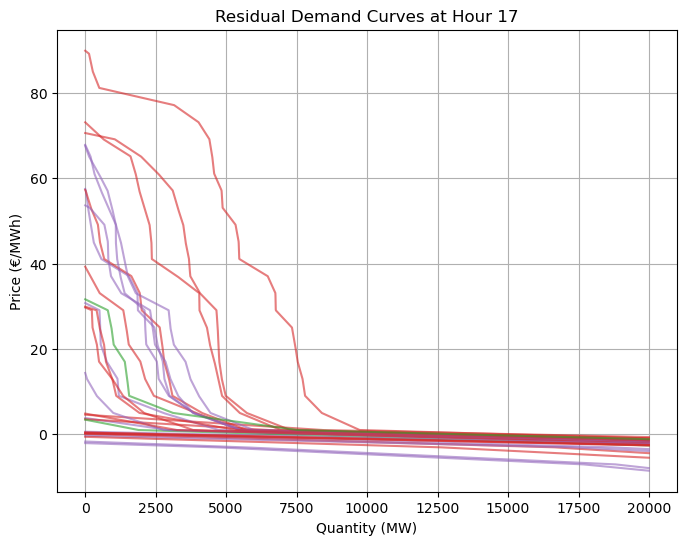

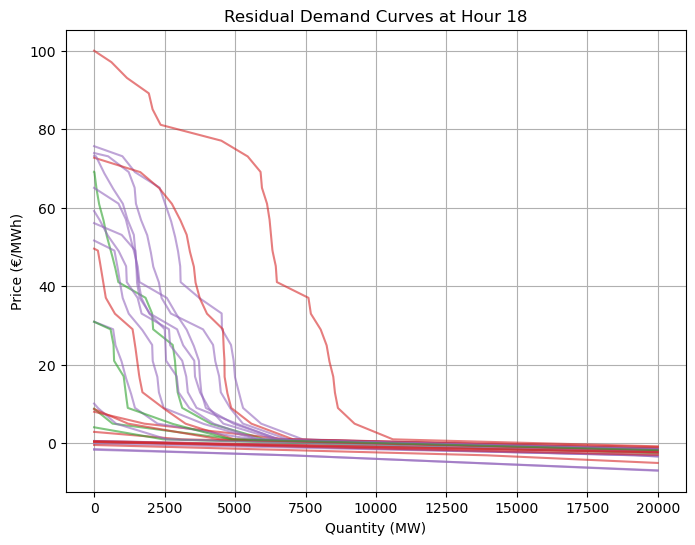

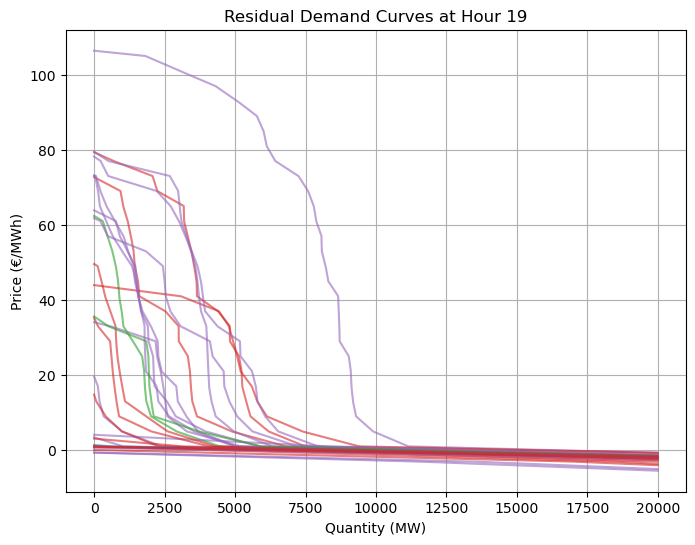

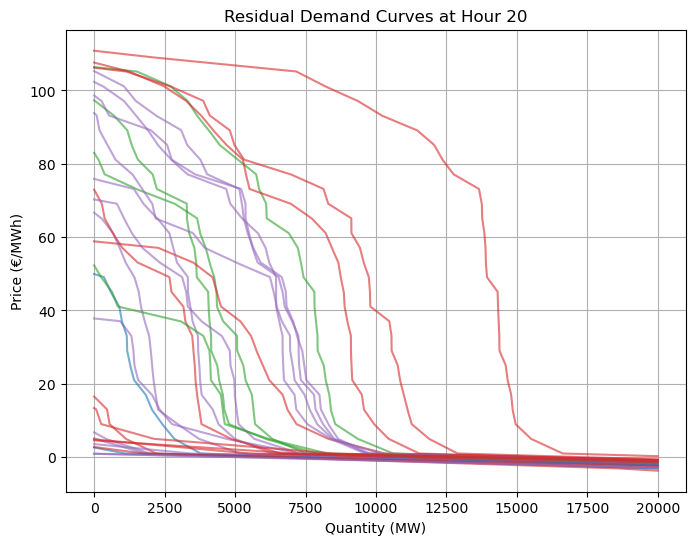

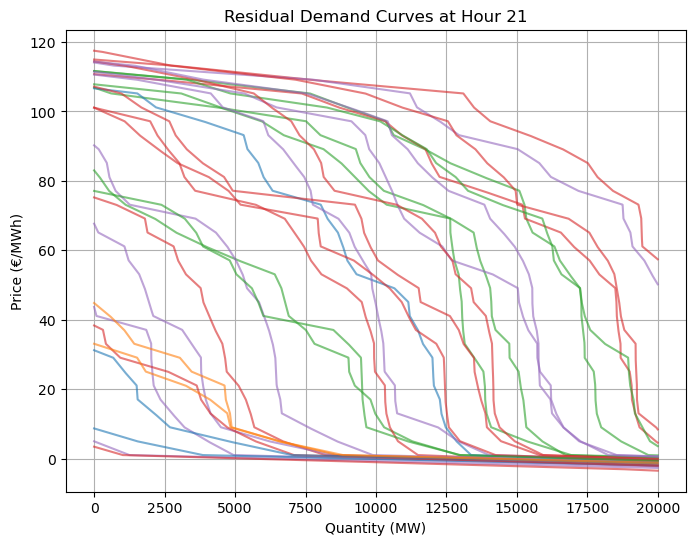

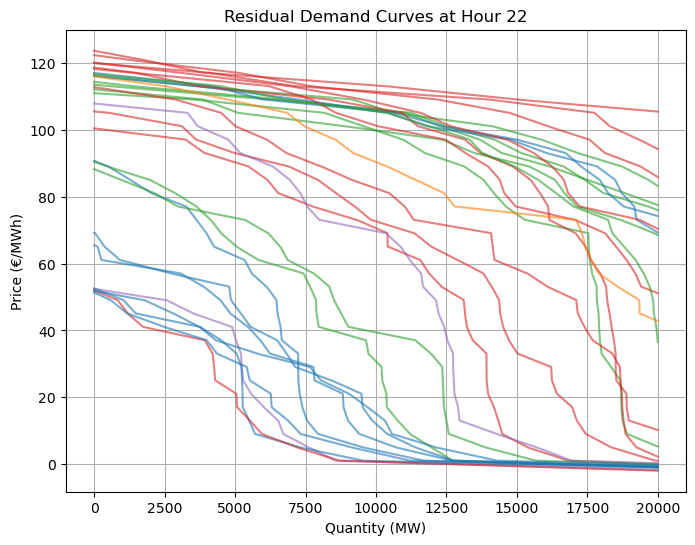

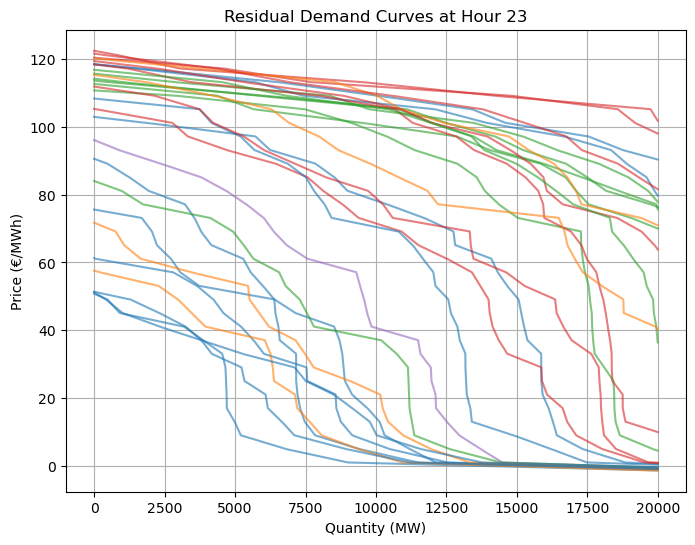

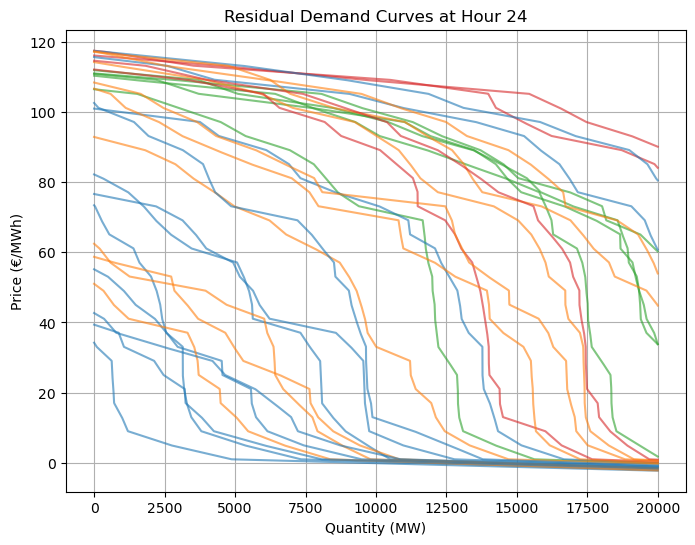

In [138]:
import matplotlib.cm as cm

colors = cm.tab10

for h in range(1, 25):  # 1~24
    plt.figure(figsize=(8,6))
    
    for curve in supply_curves:
        cluster = curve["Cluster"]
        if cluster is None:
            continue
        
        # Datetime에서 Hour 추출
        hour = int(curve["Datetime"].split()[-1])
        if hour != h:
            continue
        
        # 공급/수요곡선
        s_agg, d_agg = curve["Supply"], curve["Demand"]
        
        # 계단 보간 함수
        s_f = interp1d(
            s_agg["Price"], s_agg["Cumul"], 
            kind="previous", bounds_error=False,
            fill_value=(0, s_agg["Cumul"].iat[-1])
        )
        d_f = interp1d(
            d_agg["Price"], d_agg["Cumul"], 
            kind="previous", bounds_error=False,
            fill_value=(d_agg["Cumul"].iat[0], 0)
        )
        
        # Price grid
        pg = np.linspace(s_agg["Price"].min(), d_agg["Price"].max(), 500)
        sv, dv = s_f(pg), d_f(pg)
        
        # RDC 계산
        # wf_offer_grid = np.arange(0, s_agg["Cumul"].max() * 1.2, 100)
        wf_offer_grid = np.arange(0, 20000, 5) 

        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        
        qv, pv = zip(*rdc_pts)
        
        # RDC 플롯 (클러스터 색상 반영)
        plt.plot(qv, pv, "-", color=colors(cluster % 10), alpha=0.6)
    
    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.title(f"Residual Demand Curves at Hour {h}")
    plt.grid(True)
    plt.show()


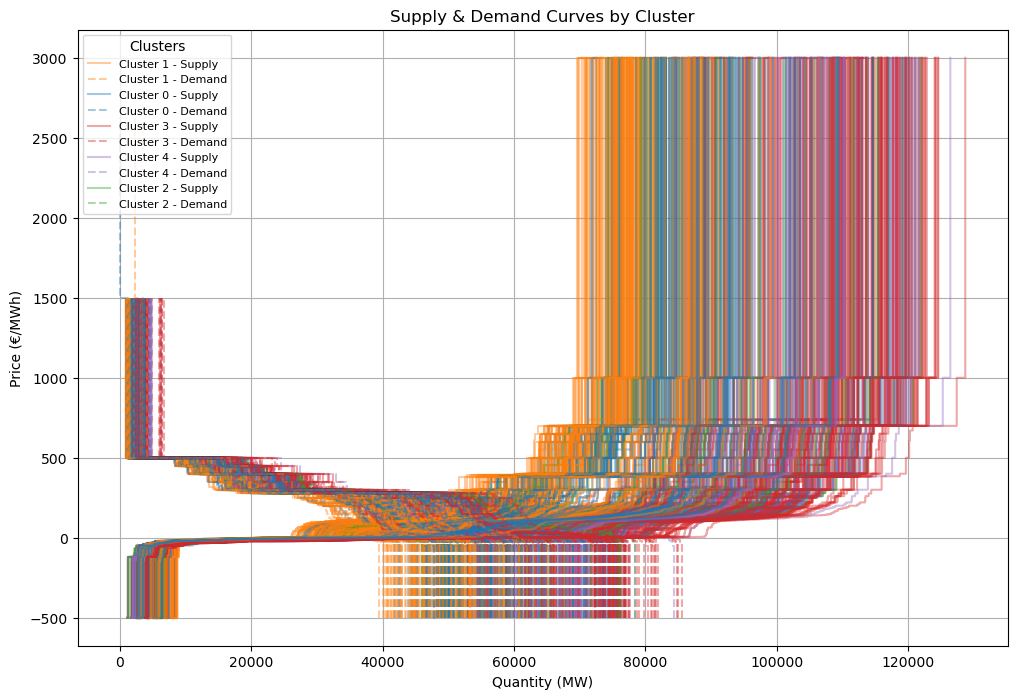

In [132]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(12, 8))

# 색상 팔레트 (클러스터 번호 → 색상)
colors = cm.tab10

for curve in supply_curves:
    cluster = curve["Cluster"]
    if cluster is None:  # 매핑 안 된 경우는 건너뜀
        continue
    
    # 공급곡선
    plt.step(
        curve["Supply"]["Cumul"], curve["Supply"]["Price"], 
        where="post", color=colors(cluster % 10), alpha=0.4,
        label=f"Cluster {cluster} - Supply" if f"Cluster {cluster} - Supply" not in plt.gca().get_legend_handles_labels()[1] else ""
    )
    
    # 수요곡선
    plt.step(
        curve["Demand"]["Cumul"], curve["Demand"]["Price"], 
        where="post", color=colors(cluster % 10), linestyle="--", alpha=0.4,
        label=f"Cluster {cluster} - Demand" if f"Cluster {cluster} - Demand" not in plt.gca().get_legend_handles_labels()[1] else ""
    )

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Supply & Demand Curves by Cluster")
plt.legend(title="Clusters", fontsize=8)
plt.grid(True)
plt.show()


In [ ]:
supply_curves = []
for (date, period), sub in df_supply.groupby(["Date", "Time Period"]):
    sup = sub[sub["GC"] == "V"].copy()
    dem = sub[sub["GC"] == "C"].copy()
    if sup.empty or dem.empty:
        continue
    
    # 공급곡선
    s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    # 수요곡선
    d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]

    # Datetime 만들기
    supply_curves.append({
        "Datetime": dt,
        "Supply": s_agg,
        "Demand": d_agg
    })

# 2. 클러스터링 결과 붙이기 (매핑 dict 활용)
cluster_map = dict(zip(df_weather["Datetime"], df_weather["Cluster"]))

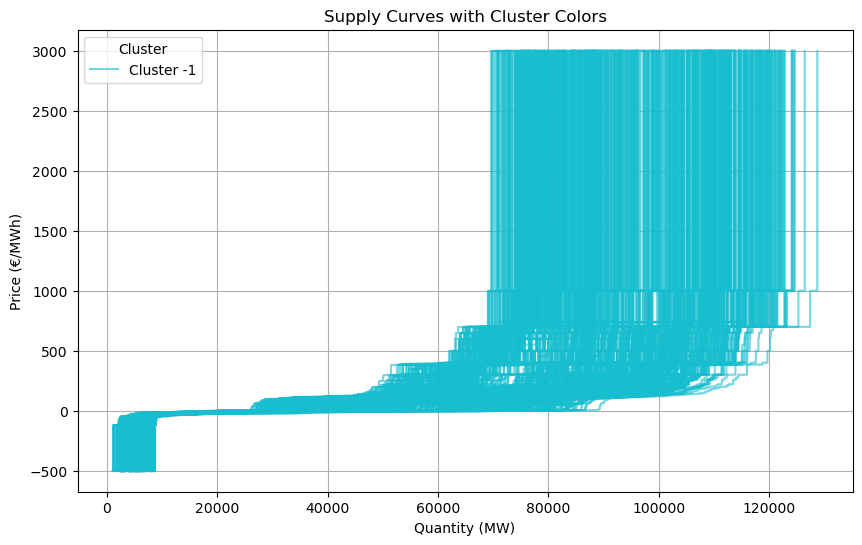

In [118]:
# 3. 시각화
plt.figure(figsize=(10,6))
for sc in supply_curves:
    dt = sc["Datetime"]
    cluster = cluster_map.get(dt, -1)  # 없는 경우 -1
    s_agg = sc["Supply"]

    plt.step(
        s_agg["Cumul"], s_agg["Price"], where="post",
        color=cm.tab10(cluster % 10),  # 클러스터 번호별 색상
        alpha=0.6,
        label=f"Cluster {cluster}" if f"Cluster {cluster}" not in plt.gca().get_legend_handles_labels()[1] else ""
    )

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Supply Curves with Cluster Colors")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

Trial 1

클러스터 대표값(centroids):
               T         ff          Prec
0  2.234898e+01   7.877551  2.979592e+00
1  3.137607e+01  16.205128  4.102564e-01
2  2.678182e+01   9.941818  6.509091e+00
3  3.552714e-15   0.000000  2.220446e-16
4  3.250417e+01  29.429167  1.458333e+00
5  2.135305e+01   4.537805  1.890244e-01
6  3.348750e+01   9.227500  2.750000e+00
7  2.103145e+01  13.112903  3.064516e-01
8  3.163464e+01   7.578431  3.071895e-01
9  3.210976e+01  20.373171  3.512195e+00


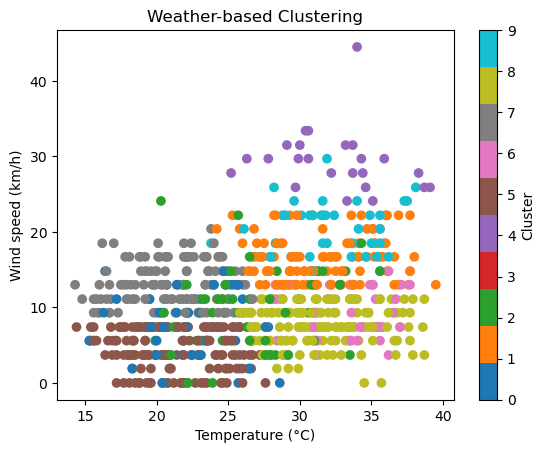

In [78]:
# 2. 분석에 쓸 feature 선택
features = df_weather[["T", "ff", "Prec"]]
# features = df_weather[["Prec"]]
features = features.replace("----", 0)
features = features.apply(pd.to_numeric, errors="coerce")  # 숫자로 변환, 변환 불가 → NaN
features = features.fillna(0)  # NaN은 0으로 대체 (필요시 다른 방식)
# 3. 정규화 (스케일 차이 보정: °C vs km/h vs mm)
scaler = StandardScaler()
X = scaler.fit_transform(features)

# 4. KMeans 클러스터링 (예: 3개 클러스터)
kmeans = KMeans(n_clusters=10, random_state=42)
df_weather["Cluster"] = kmeans.fit_predict(X)

# 5. 클러스터 중심(대표 날씨 패턴) 출력
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                         columns=features.columns)
print("클러스터 대표값(centroids):\n", centroids)

# 6. 시각화 (기온-풍속 기준으로 클러스터 표시)
plt.scatter(df_weather["T"], df_weather["ff"], c=df_weather["Cluster"], cmap="tab10")
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind speed (km/h)")
plt.title("Weather-based Clustering")
plt.colorbar(label="Cluster")
plt.show()

In [74]:
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i],       resid[i+1]
            if r1 != r0:
                # 선형 보간으로 교차점 계산
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc

wf_offer_grid = np.arange(0, 20000, 5) 


In [70]:
# import glob

# 1. 모든 공급곡선 파일 읽어오기
files = glob.glob("filteredcurve_202507*.csv")  # 경로 맞게 수정
df_list = []
for fn in files:
    temp = pd.read_csv(fn, encoding="utf-8-sig")
    # 파일명에서 날짜 추출
    date_str = fn.split("_")[-1].split(".")[0]   # e.g. "20250720"
    temp["Date"] = pd.to_datetime(date_str, format="%Y%m%d")
    df_list.append(temp)

df_supply = pd.concat(df_list, ignore_index=True)

# 2. 날짜 → 클러스터 번호 매핑
df_supply["Cluster"] = df_supply["Date"].map(date_cluster_map)

print(df_supply.head())
print(df_supply["Date"].unique())
print(df_supply["Cluster"].unique())


   Time Period       Date Pais  Unidad GC  Amount    Price  \
0          1.0 2025-07-01   MI     NaN  C   489.7  1500.00   
1          1.0 2025-07-01   MI     NaN  C     7.2  1500.00   
2          1.0 2025-07-01   MI     NaN  C   227.7  1500.00   
3          1.0 2025-07-01   MI     NaN  C     0.1   800.00   
4          1.0 2025-07-01   MI     NaN  C     0.1   700.05   

  Ofertada (O)/Casada (C) Tipología de Oferta  Unnamed: 9  Cluster  
0                       O                   S         NaN        1  
1                       O                   S         NaN        1  
2                       O                   S         NaN        1  
3                       O                   S         NaN        1  
4                       O                   S         NaN        1  
<DatetimeArray>
['2025-07-01 00:00:00', '2025-07-02 00:00:00', '2025-07-03 00:00:00',
 '2025-07-04 00:00:00', '2025-07-05 00:00:00', '2025-07-06 00:00:00',
 '2025-07-07 00:00:00', '2025-07-08 00:00:00', '2025-07-0

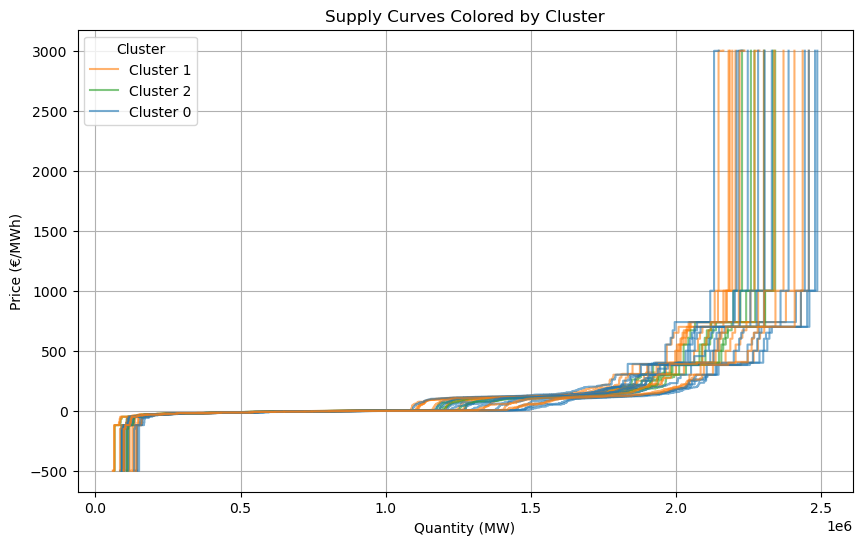

In [72]:
import matplotlib.cm as cm

plt.figure(figsize=(10,6))
for date in df_supply["Date"].unique():
    sub = df_supply[df_supply["Date"] == date]
    cluster = int(sub["Cluster"].iloc[0])  # 클러스터 번호
    
    sup = sub[sub["GC"] == "V"].copy()
    if sup.empty:
        continue
    
    s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    plt.step(
        s_agg["Cumul"], s_agg["Price"], where="post",
        color=cm.tab10(cluster),  # cluster 번호를 색상으로 매핑
        alpha=0.6,
        label=f"Cluster {cluster}" if f"Cluster {cluster}" not in plt.gca().get_legend_handles_labels()[1] else ""
    )

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Supply Curves Colored by Cluster")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


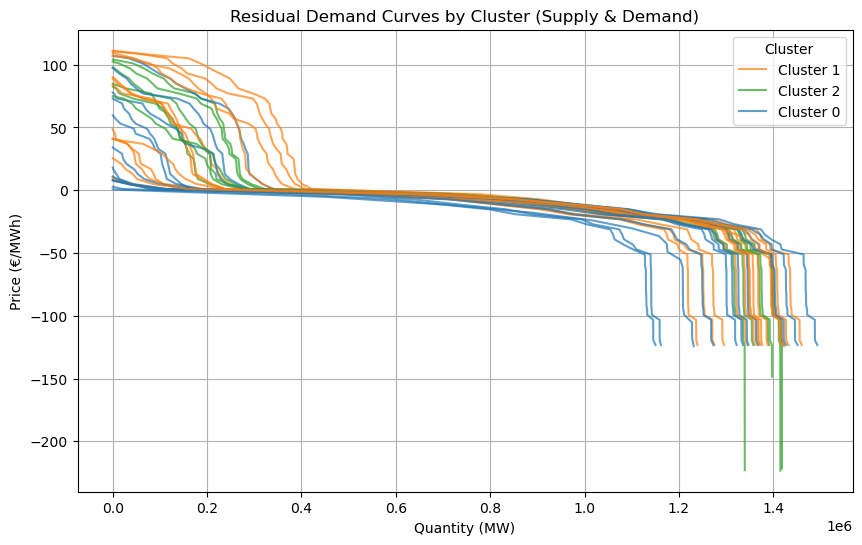

In [55]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import interp1d
# from scipy.optimize import root_scalar
# import matplotlib.cm as cm

def compute_rdc(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0, p1 = price_grid[i], price_grid[i+1]
            r0, r1 = resid[i], resid[i+1]
            if r1 != r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc

plt.figure(figsize=(10,6))

for date in df_supply["Date"].unique():
    sub = df_supply[df_supply["Date"] == date]
    cluster = int(sub["Cluster"].iloc[0])  # 해당 날짜의 클러스터 번호

    # 공급곡선 (GC == 'V')
    sup = sub[sub["GC"] == "V"].copy()
    s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    s_agg["Cumul"] = s_agg["Amount"].cumsum()

    # 수요곡선 (GC == 'C')
    dem = sub[sub["GC"] == "C"].copy()
    d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]

    # 계단 보간 함수 만들기
    s_f = interp1d(
        s_agg["Price"], s_agg["Cumul"], kind="previous",
        bounds_error=False, fill_value=(0, s_agg["Cumul"].iat[-1])
    )
    d_f = interp1d(
        d_agg["Price"], d_agg["Cumul"], kind="previous",
        bounds_error=False, fill_value=(d_agg["Cumul"].iat[0], 0)
    )

    # 가격 그리드 생성
    pg = np.linspace(s_agg["Price"].min(), d_agg["Price"].max(), 500)
    sv = s_f(pg)
    dv = d_f(pg)

    # RDC 계산
    wf_offer_grid = np.arange(0, s_agg["Cumul"].max() * 1.2, 100)
    rdc_pts = compute_rdc(pg, dv, sv, wf_offer_grid)
    if not rdc_pts:
        continue

    qv, pv = zip(*rdc_pts)
    plt.plot(qv, pv, '-', color=cm.tab10(cluster), alpha=0.7,
             label=f"Cluster {cluster}" if f"Cluster {cluster}" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("Residual Demand Curves by Cluster (Supply & Demand)")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


## 클러스터링